# Heatmaps (Feature Sets)

This notebook builds correlation heatmaps per feature set using a combined train + val + test split.

**Data sources**
- Feature sets 01–05: `splits/base`
- Feature set 06: `splits/derived`
- Feature sets 07–11: `splits/derived_all`


## Feature Sets


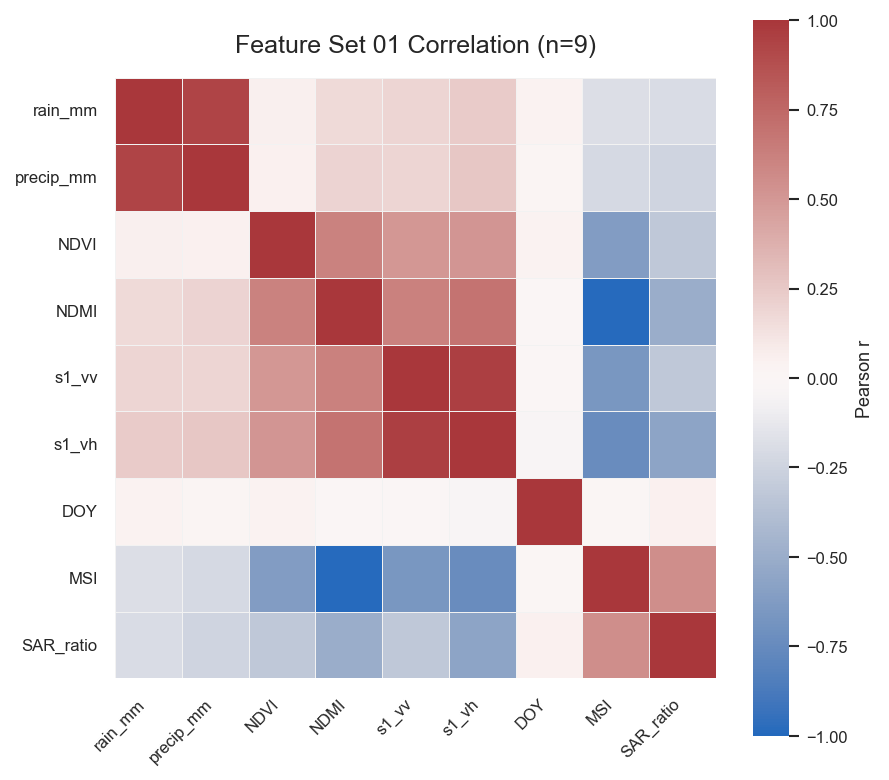

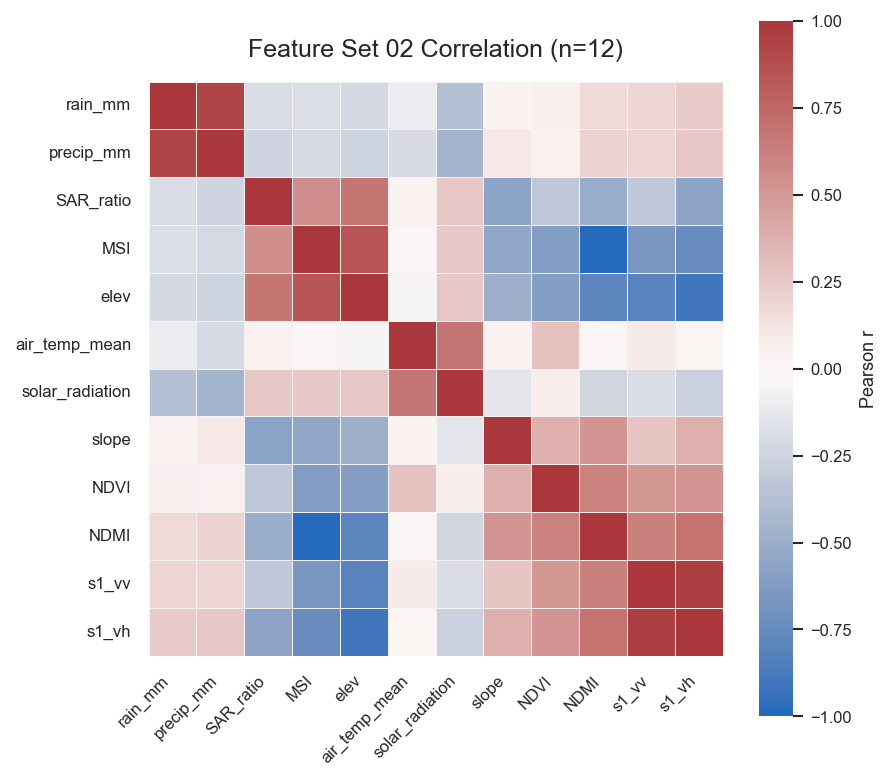

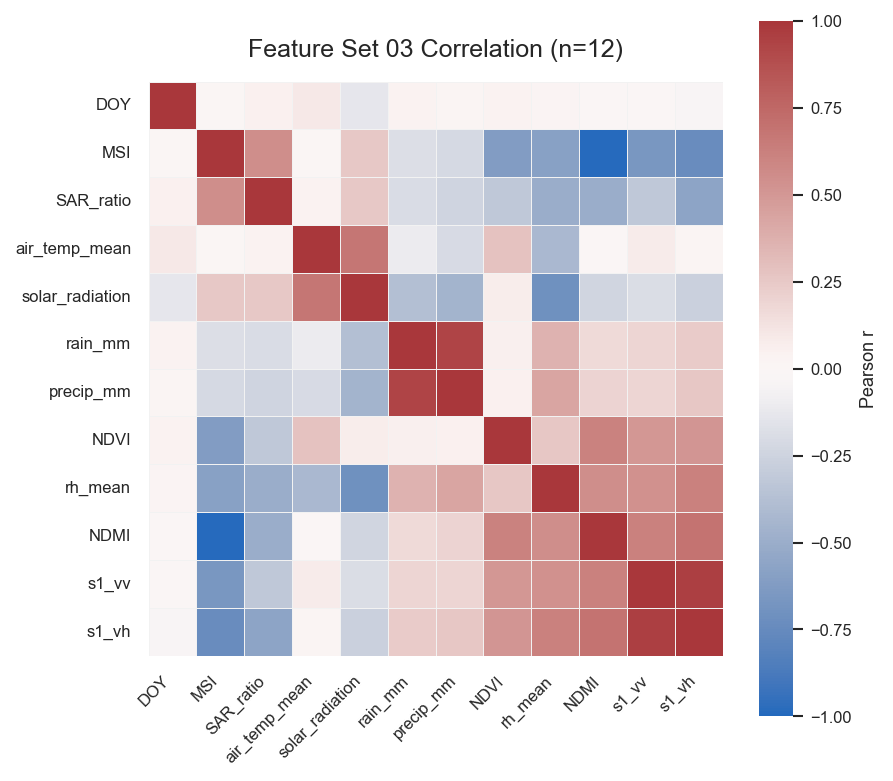

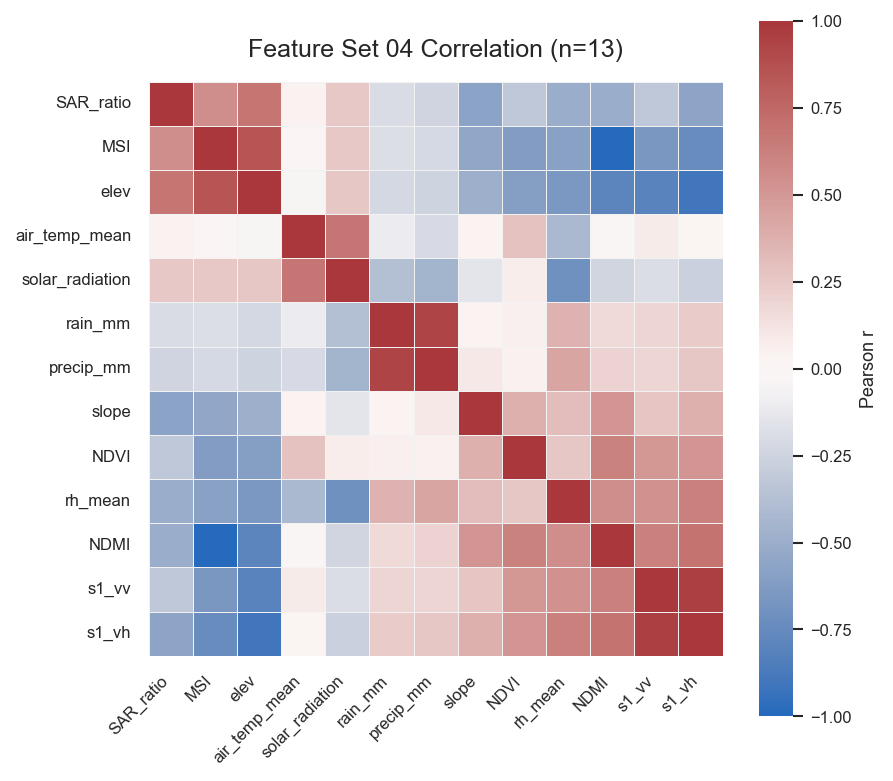

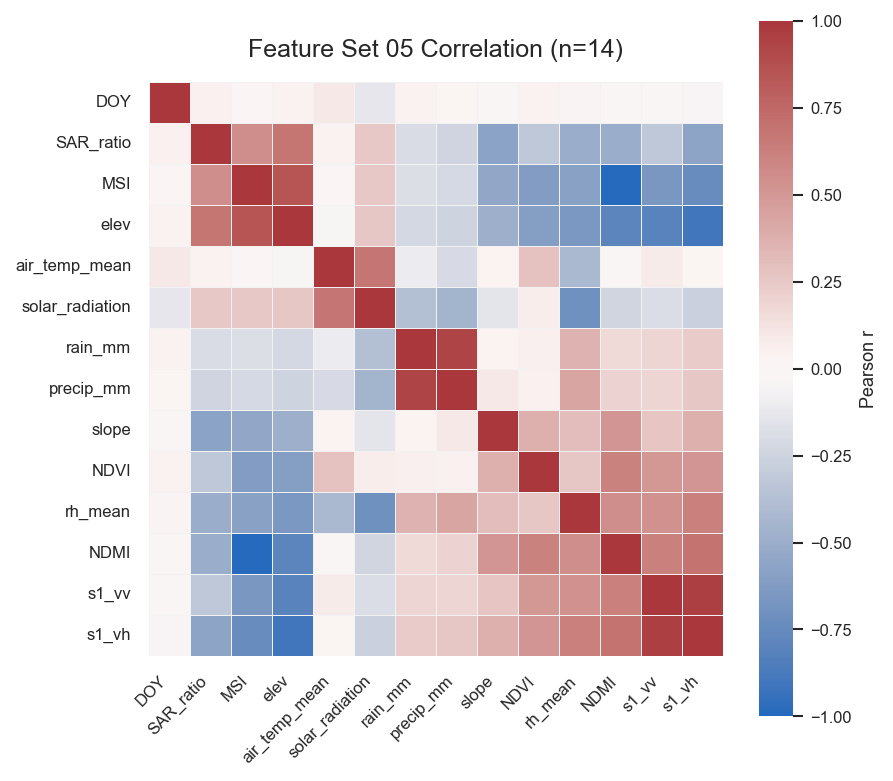

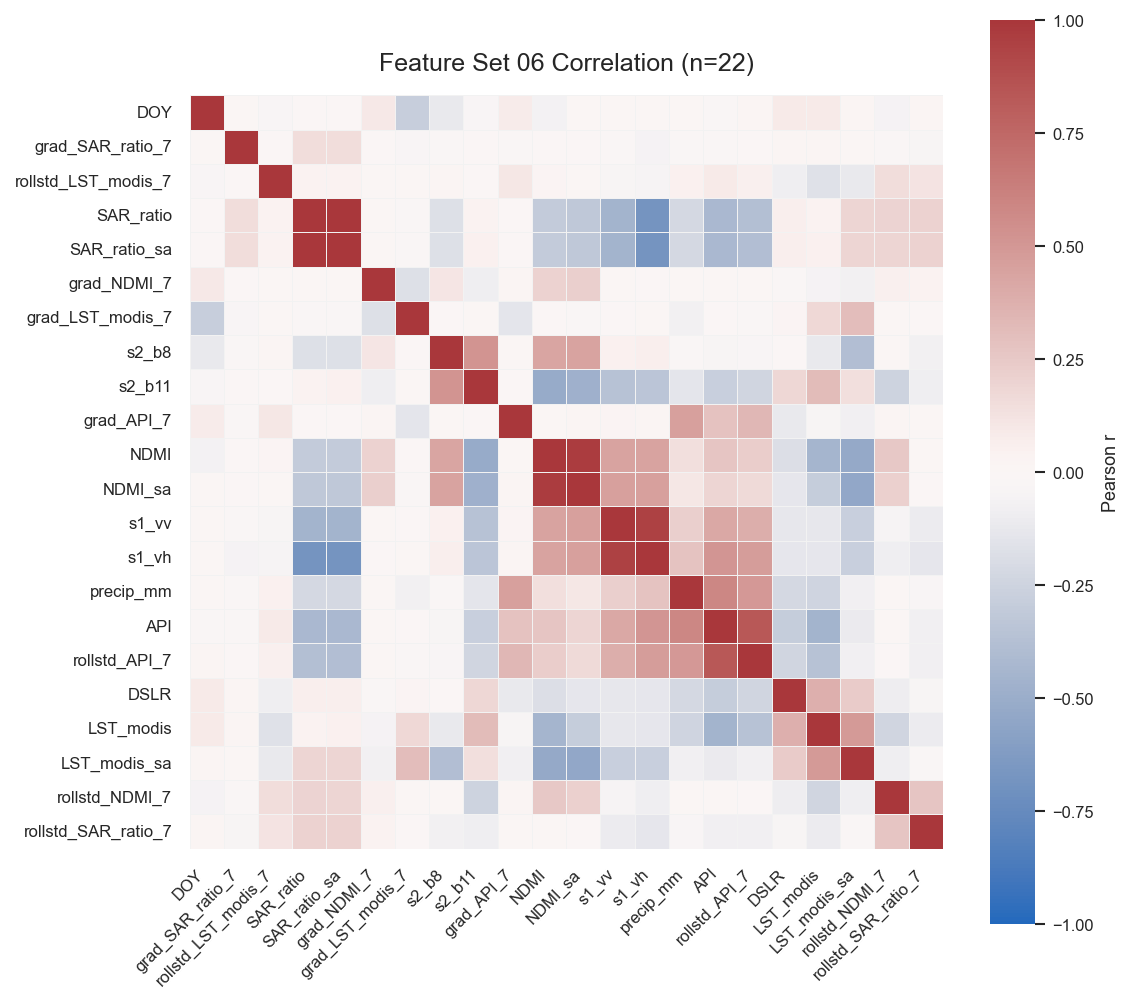

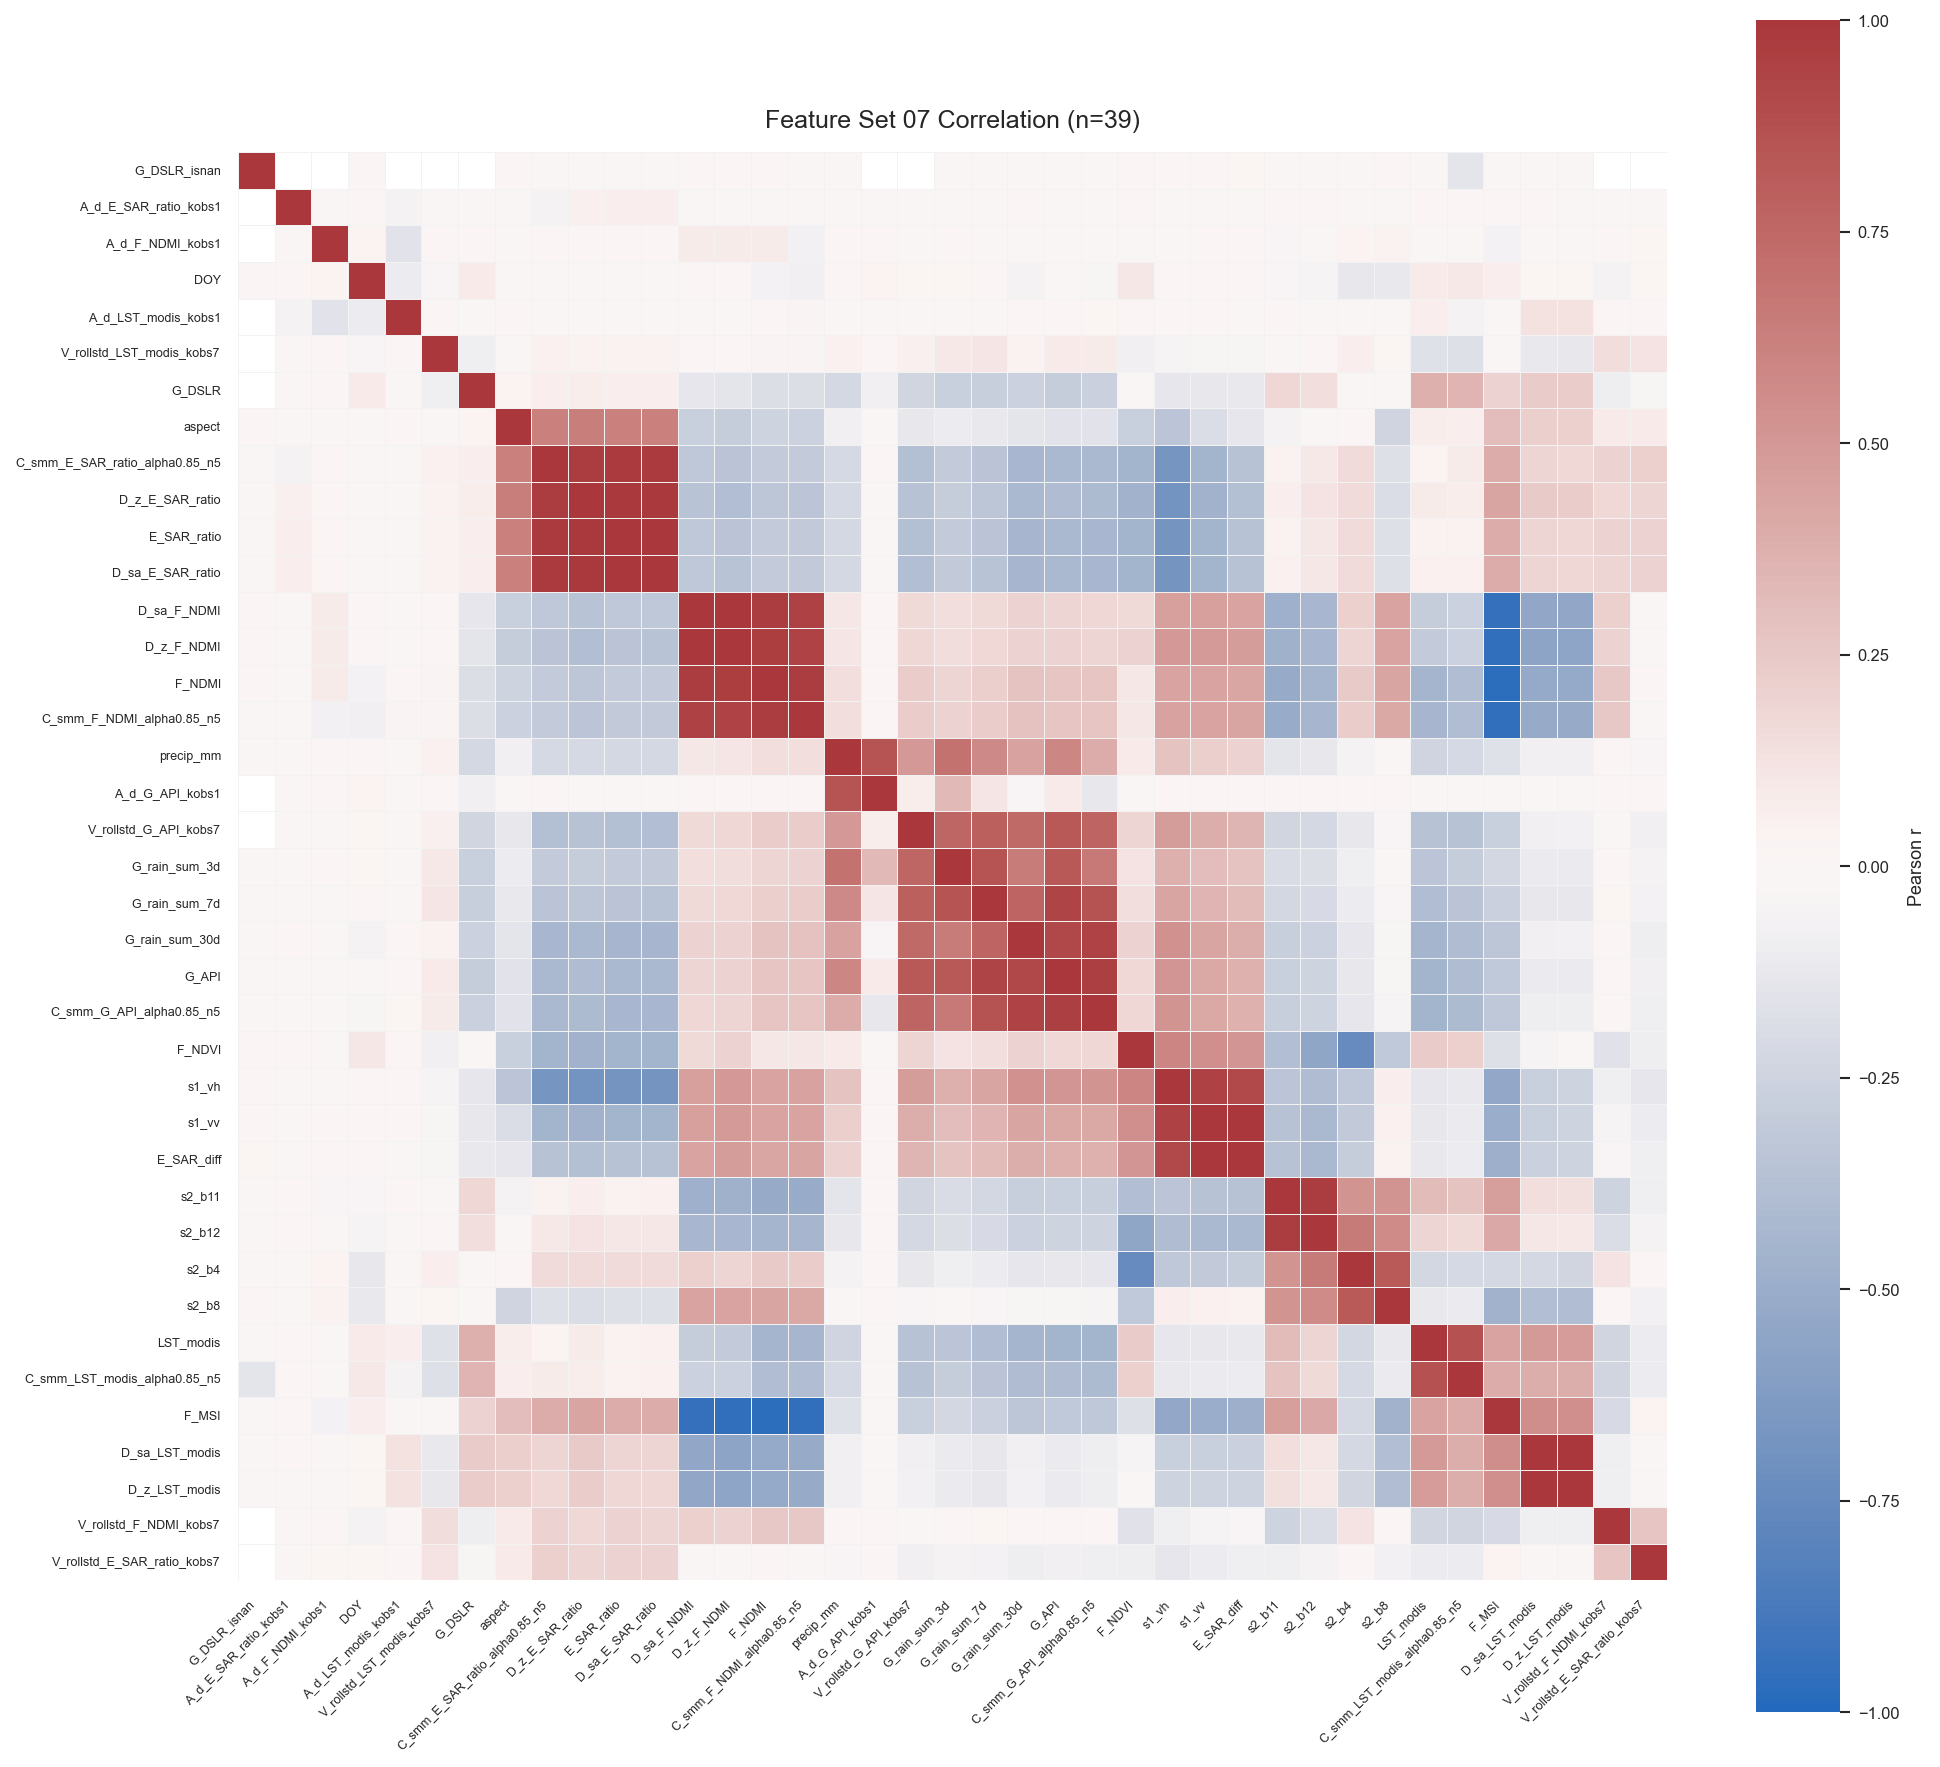

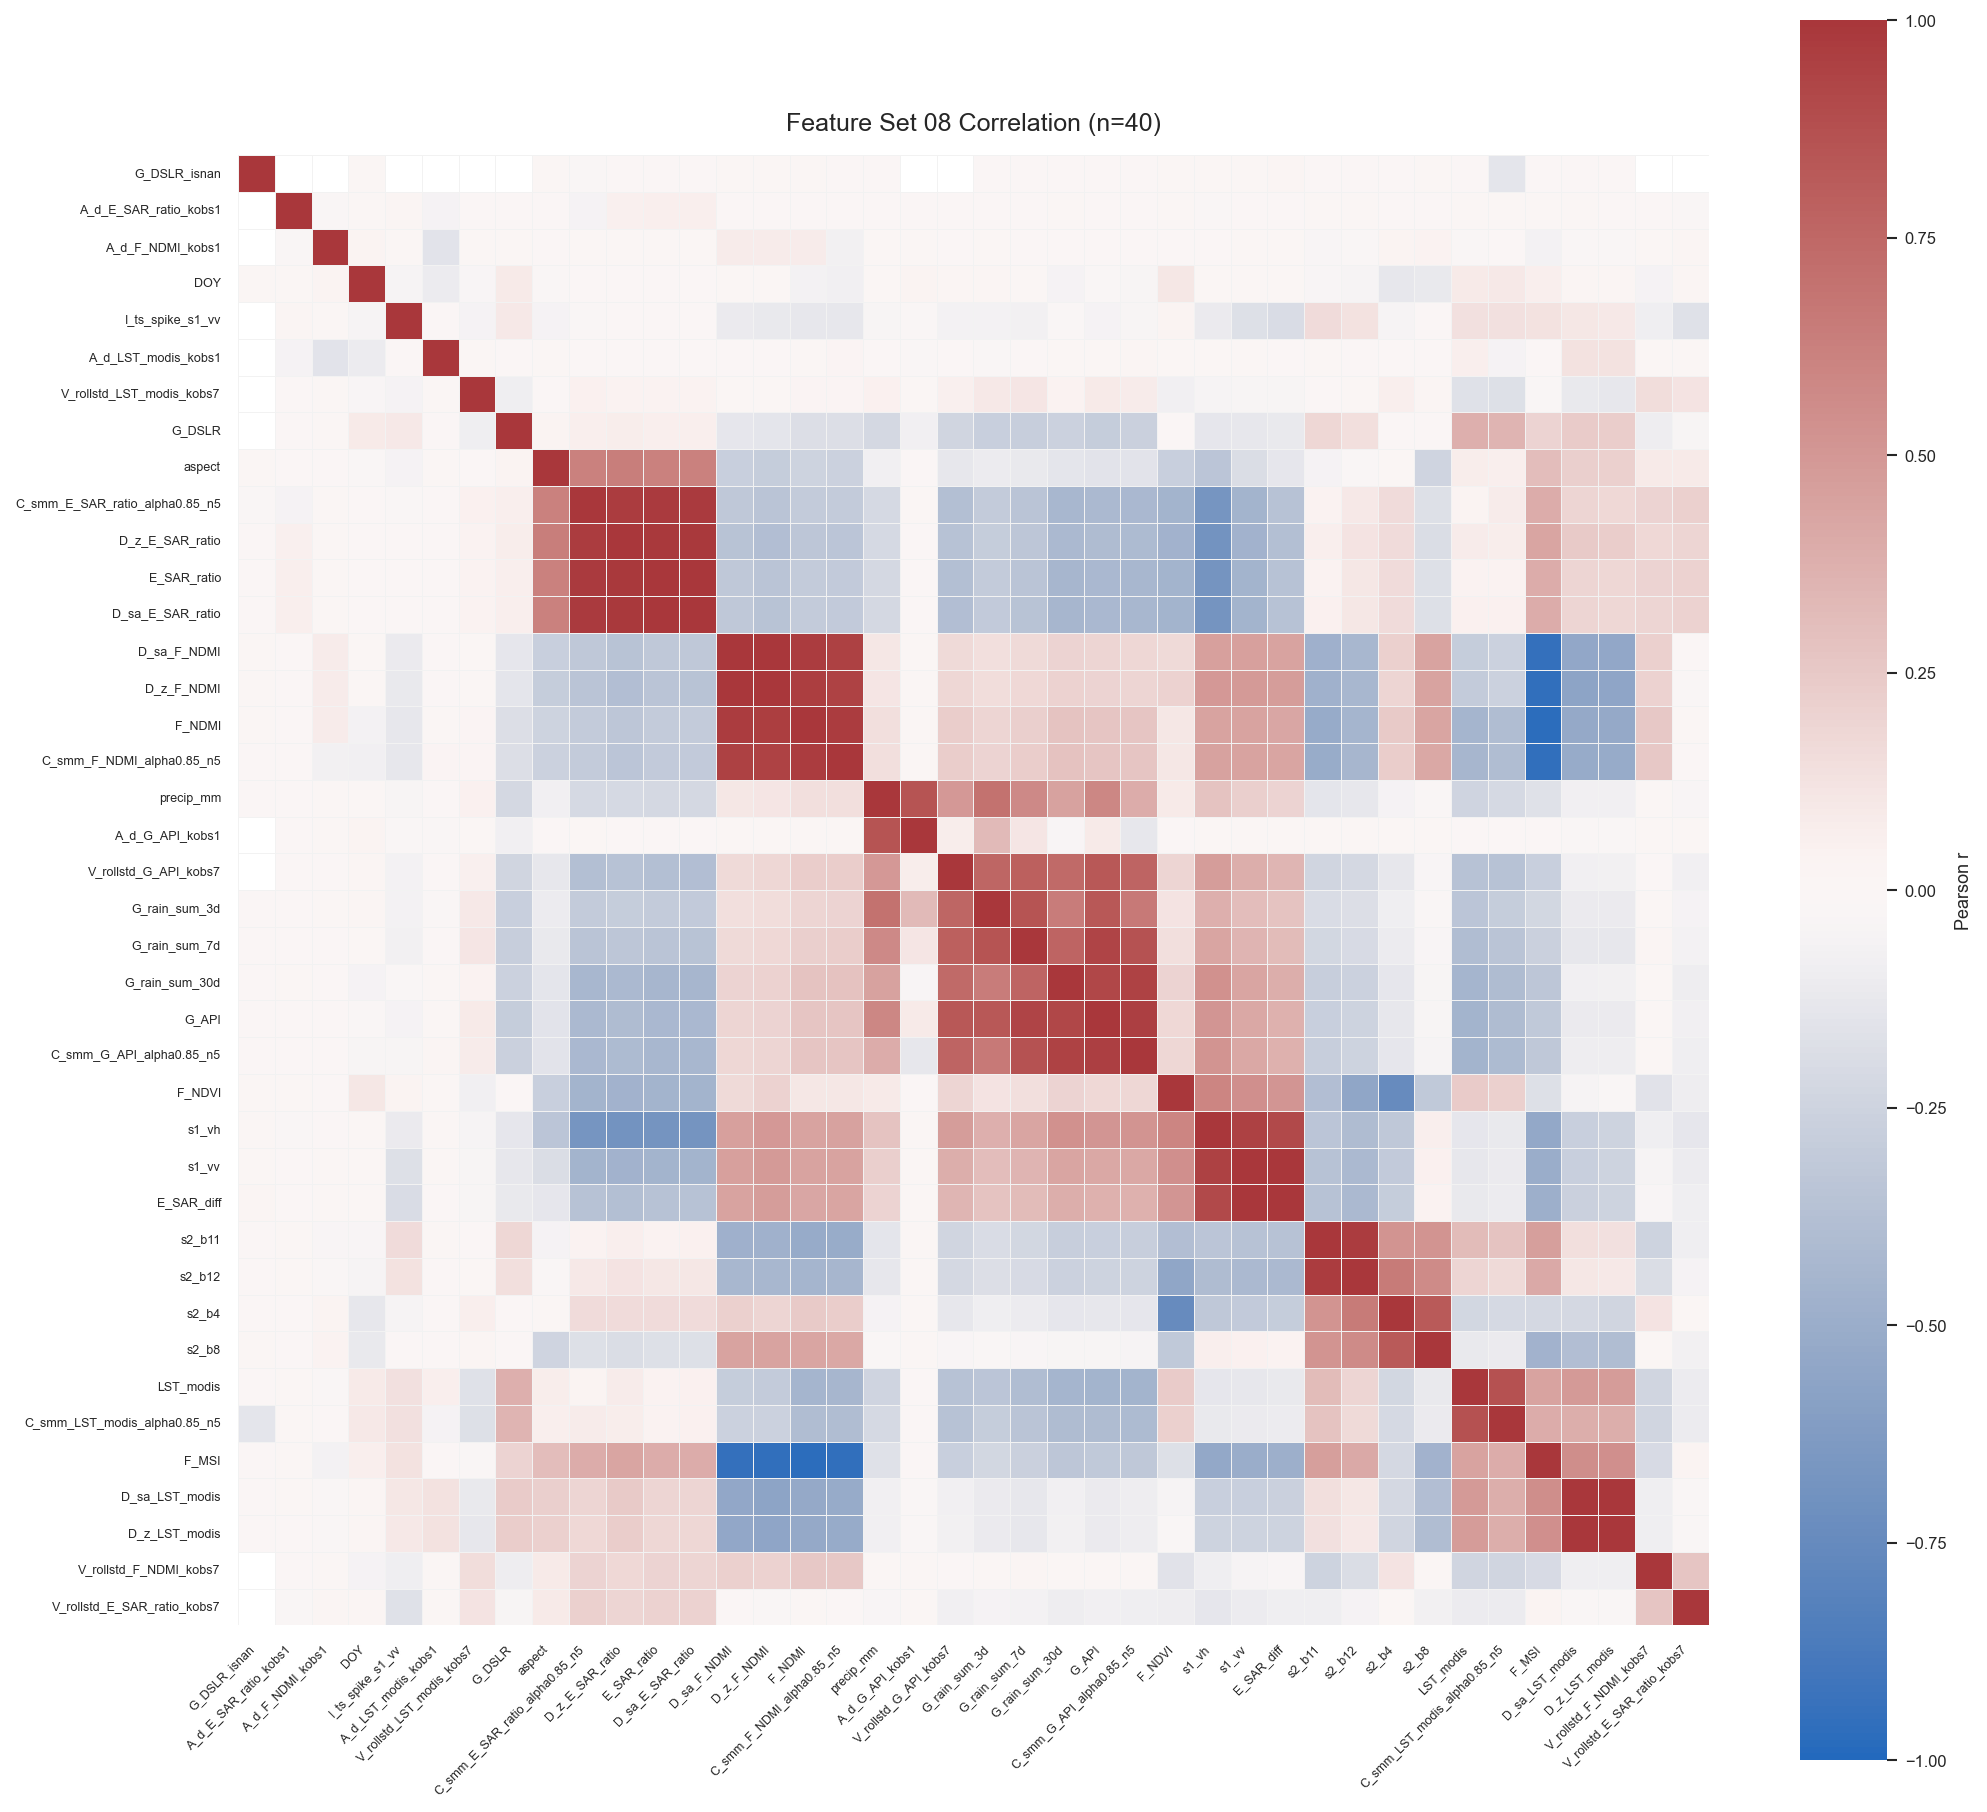

Missing columns (ignored): ['days_since_rain_event', 'rain_mm_impulse_0_7', 'rain_event_impulse_0_7']


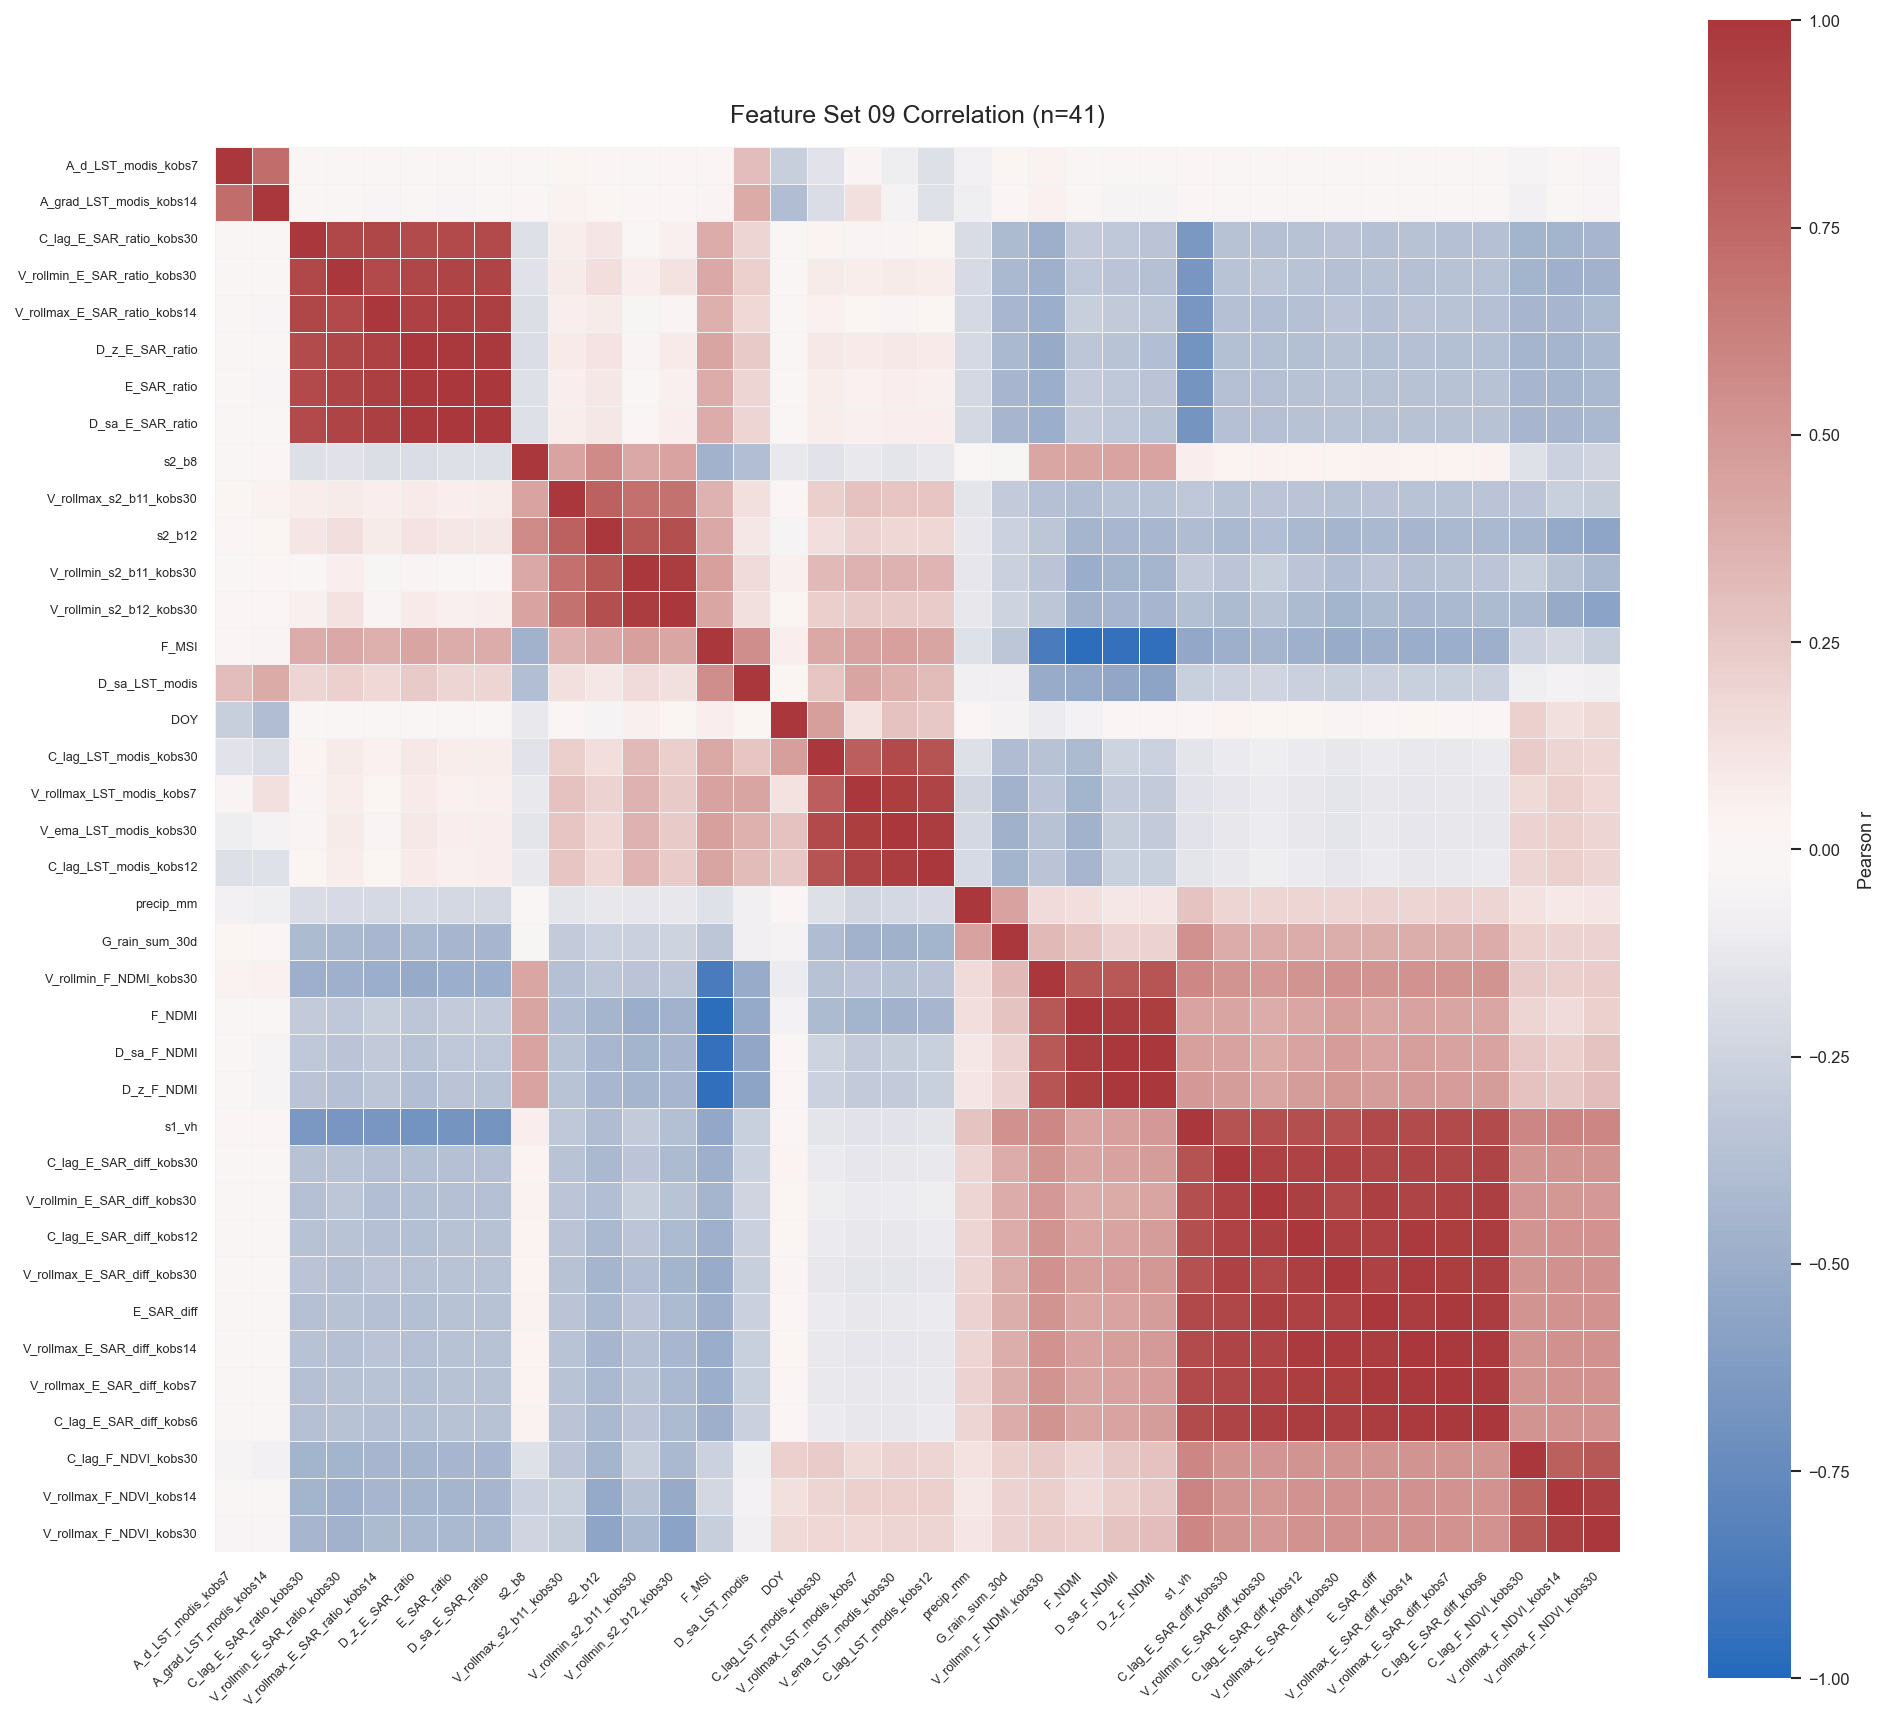

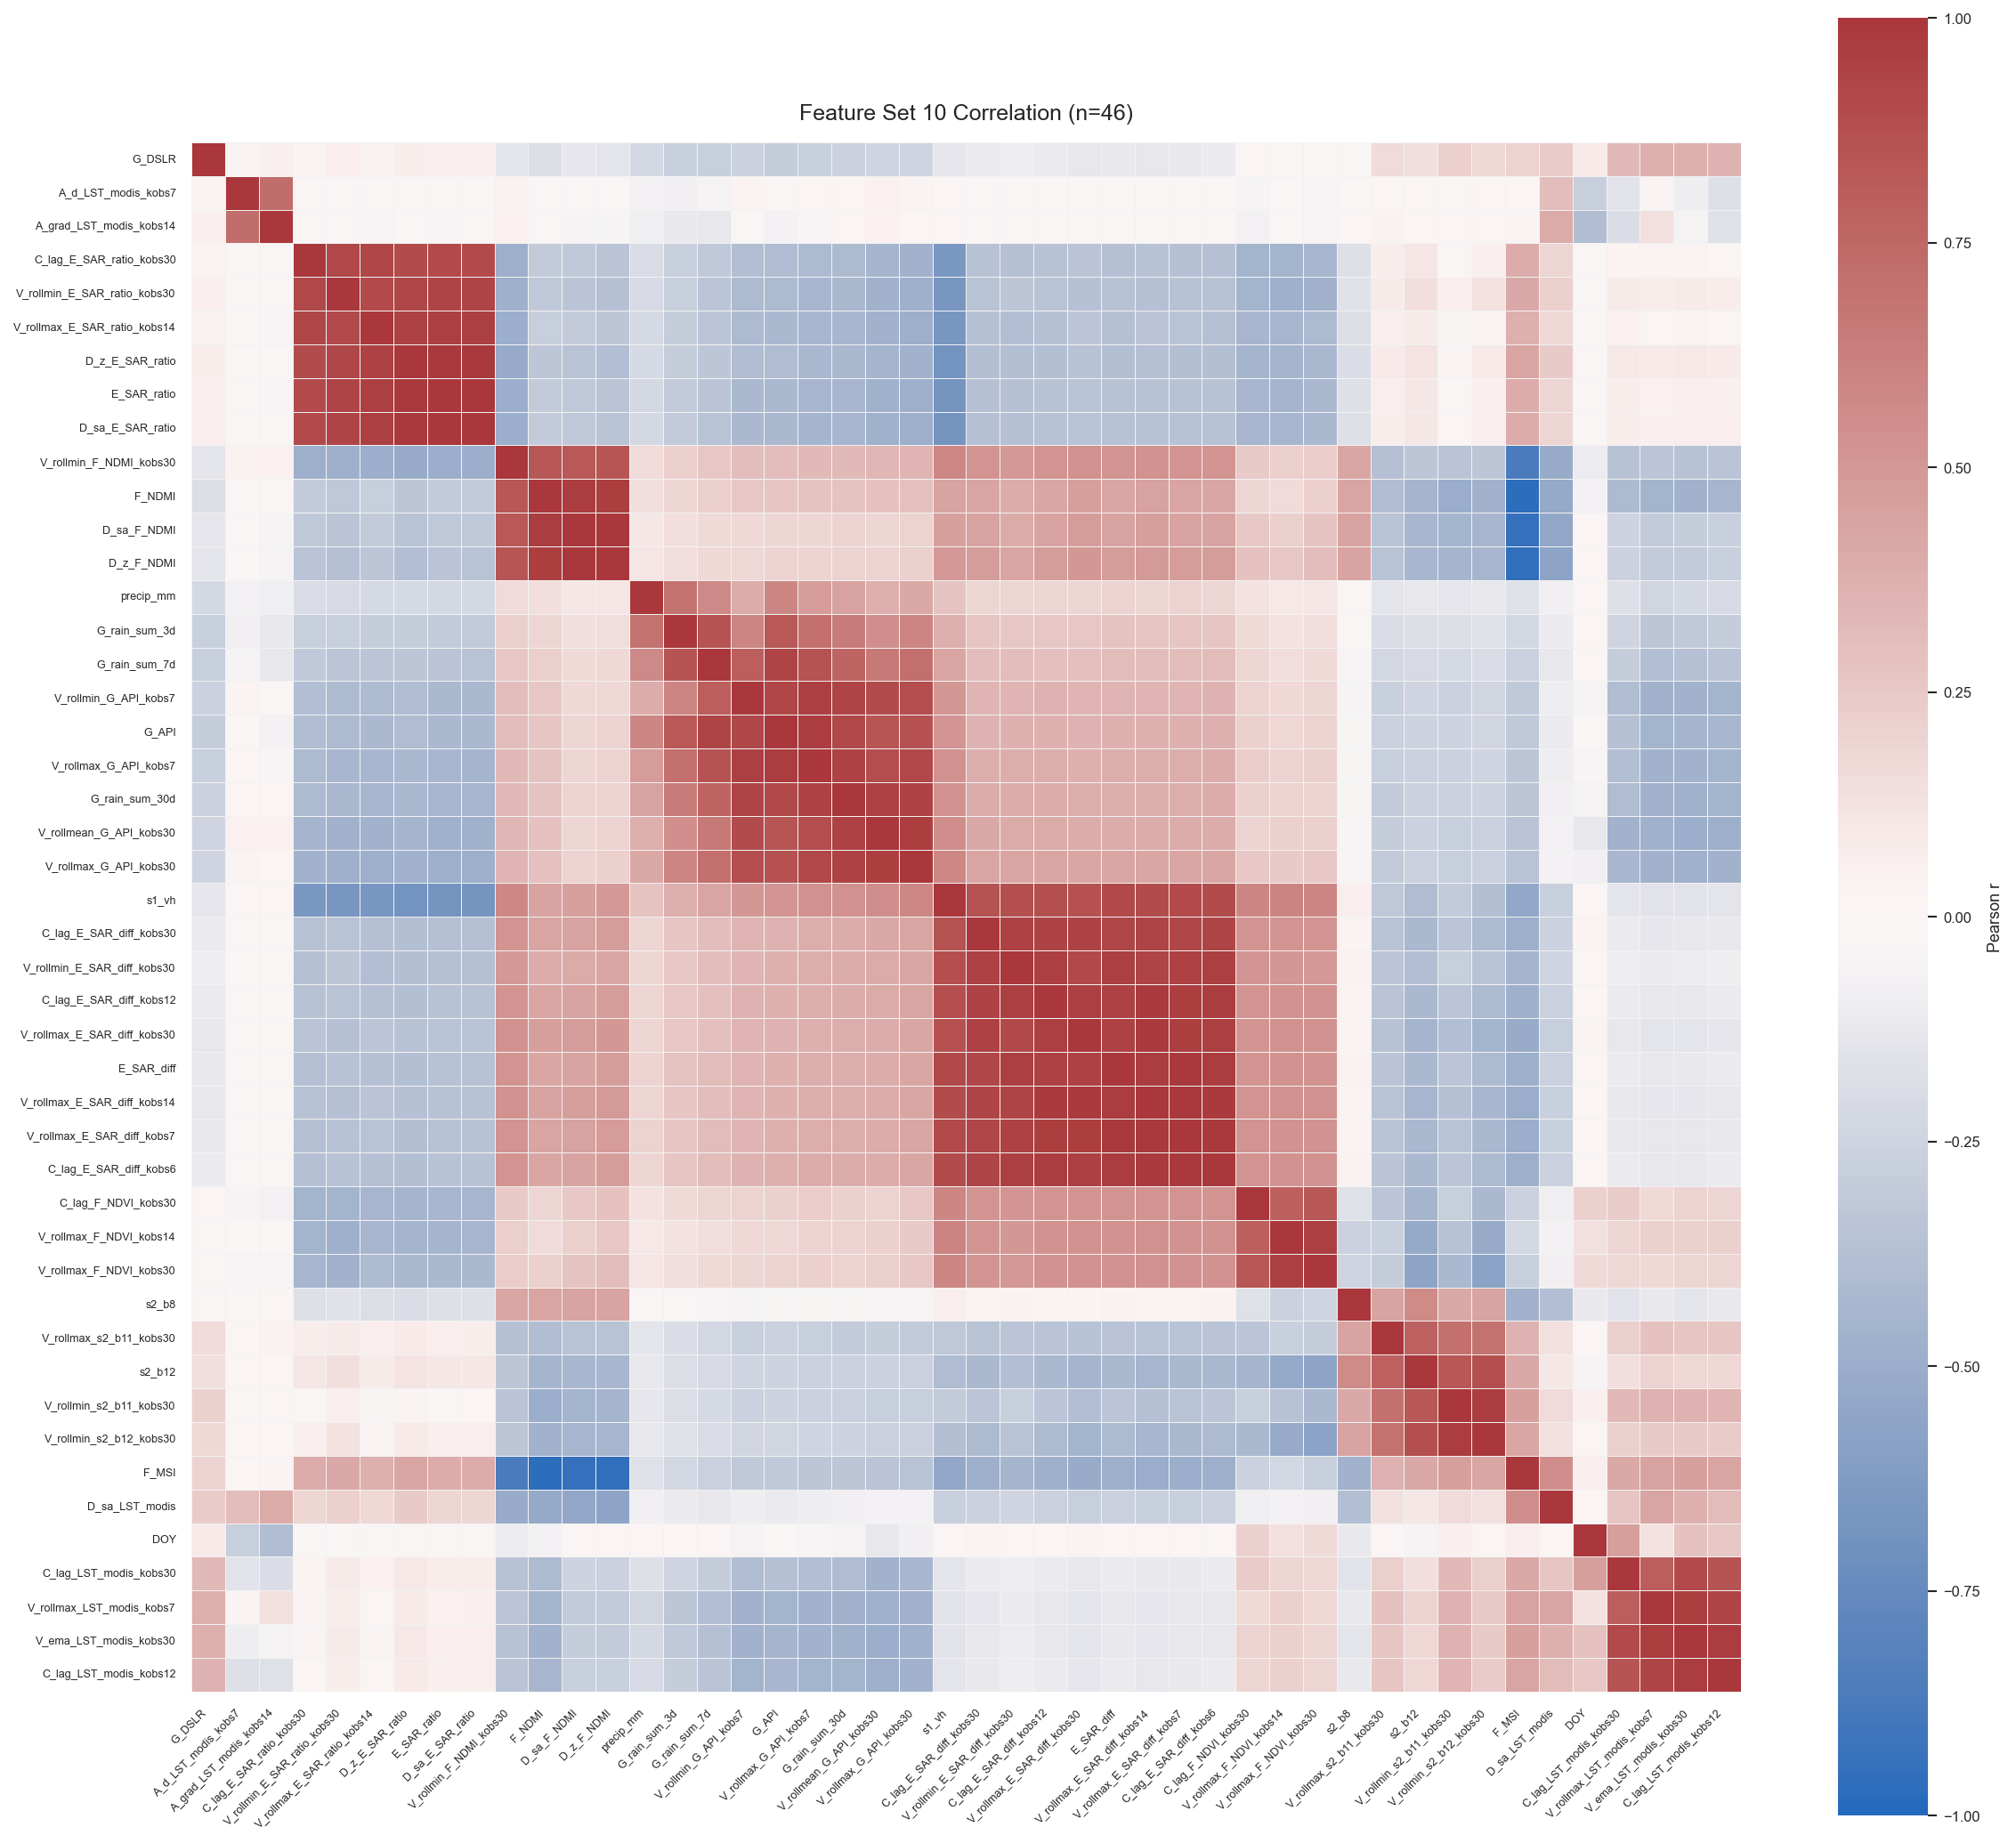

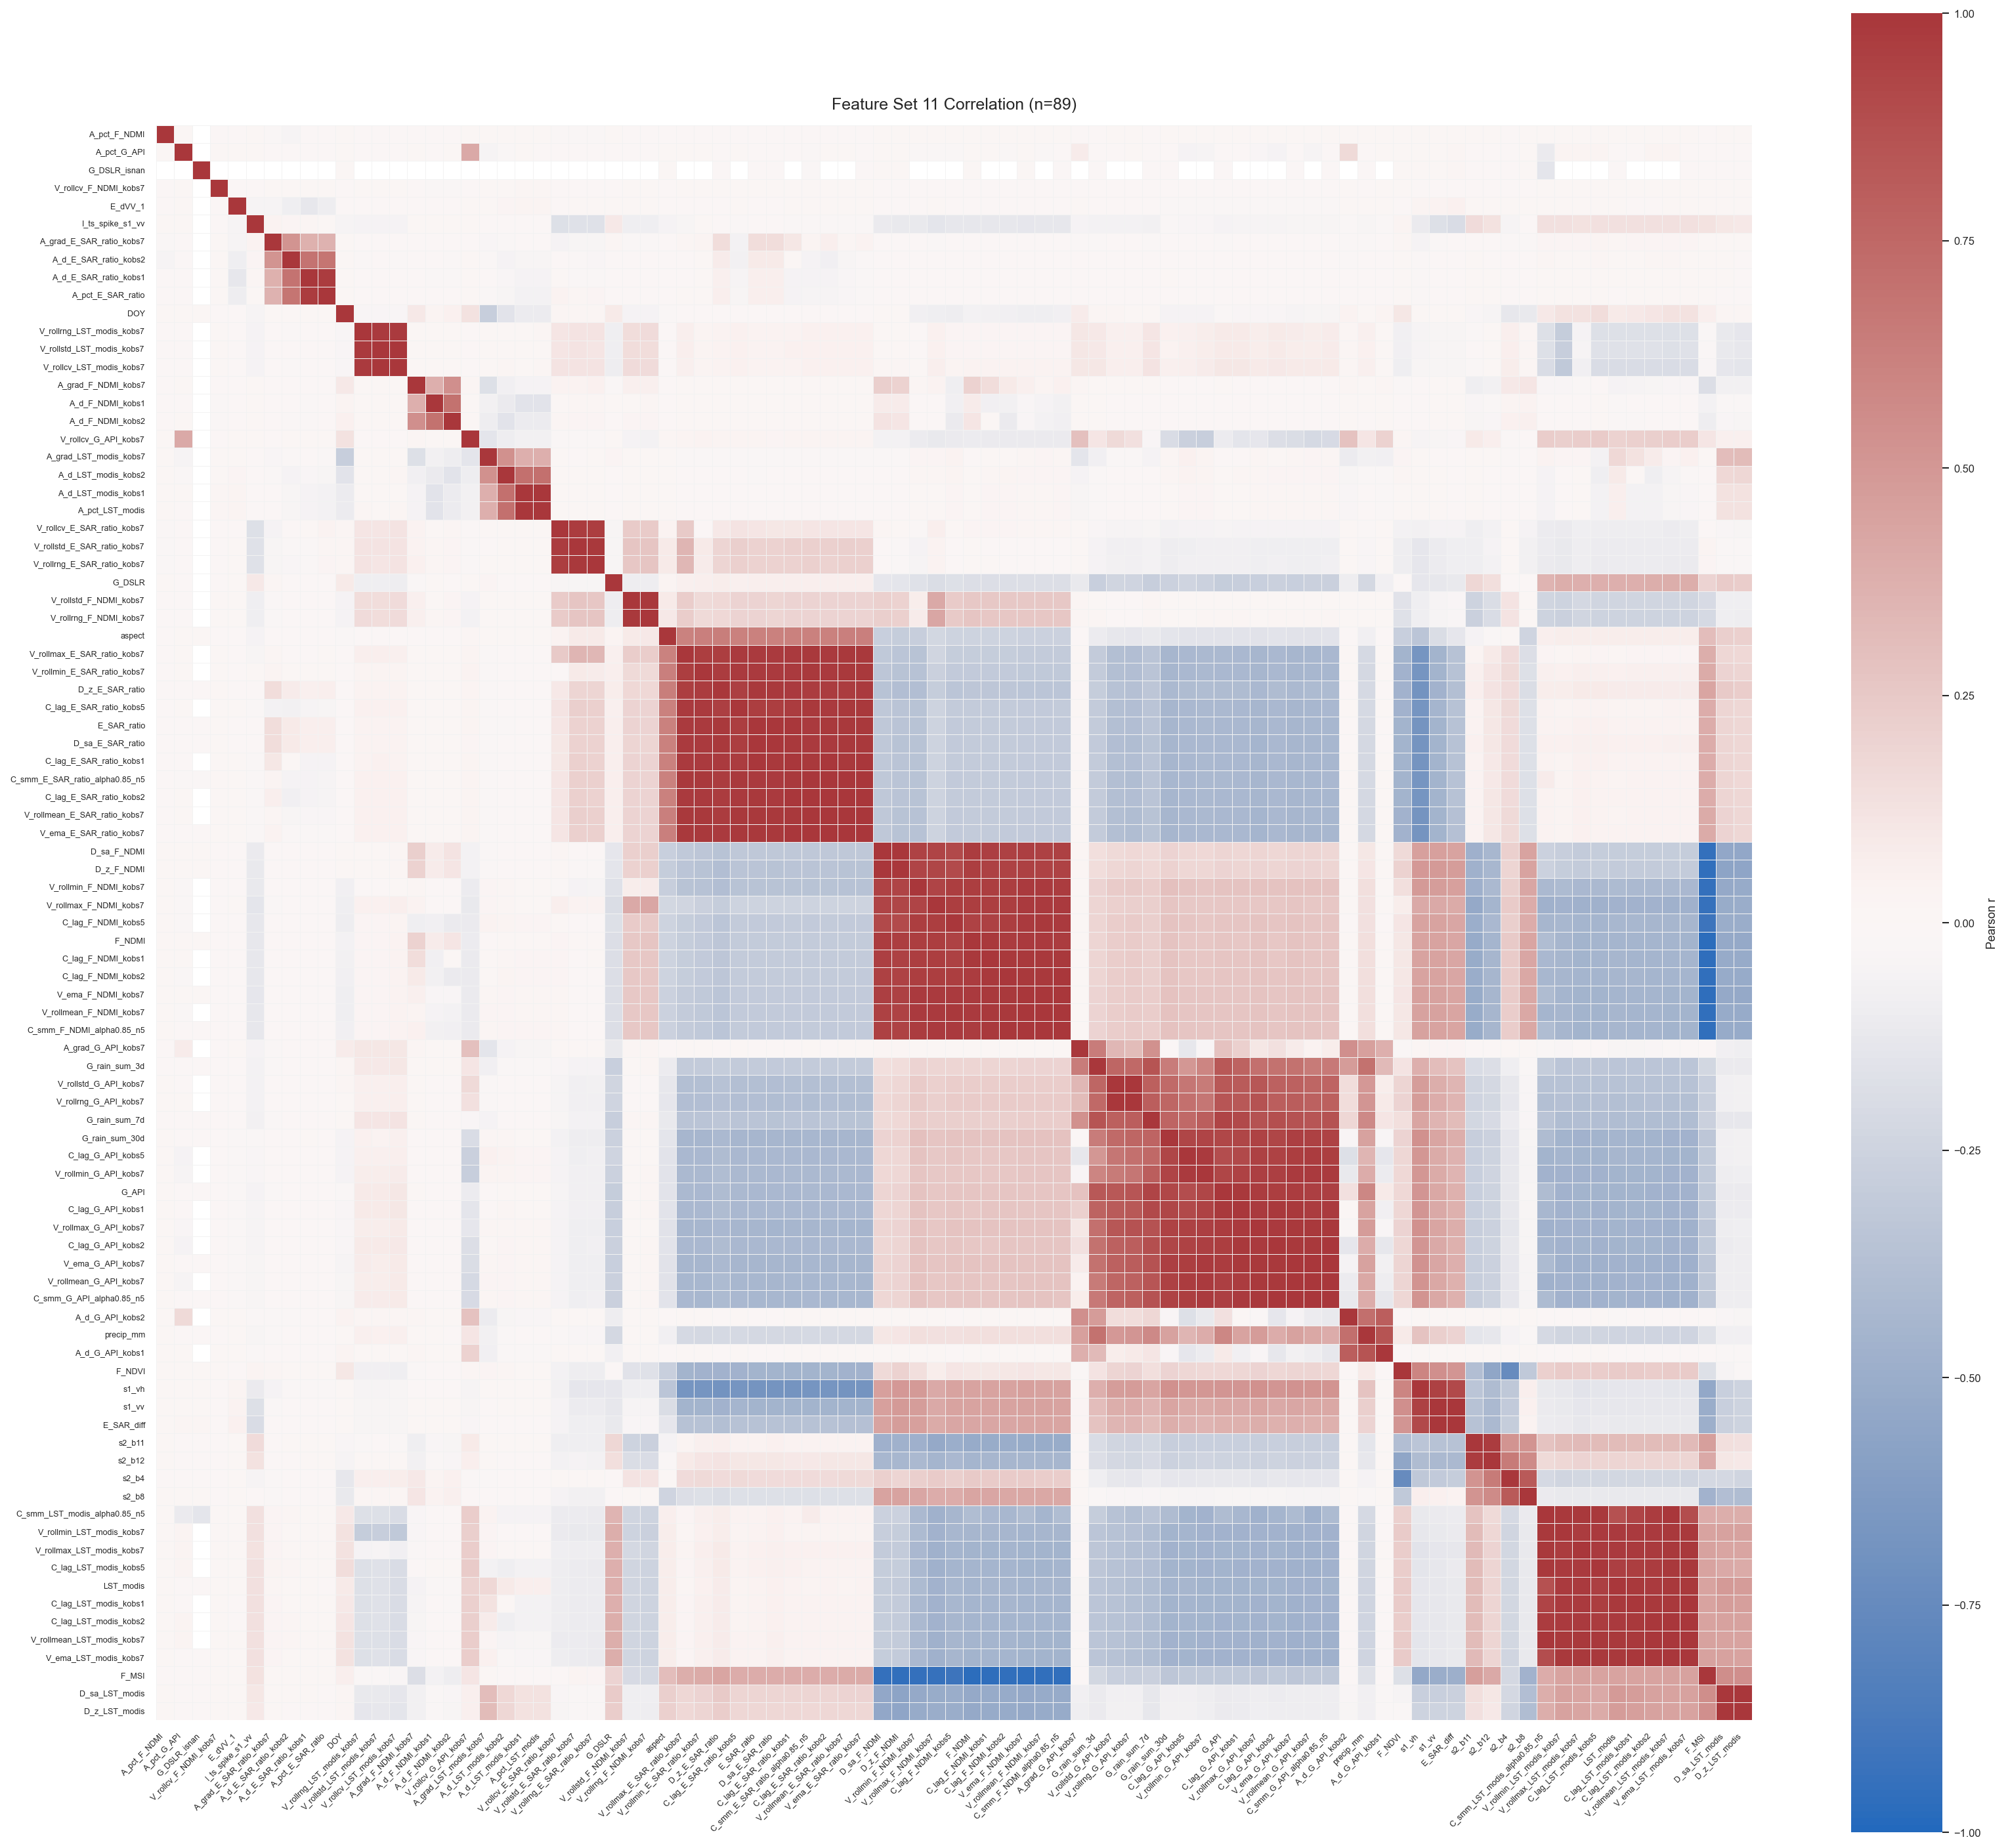

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from scipy.cluster.hierarchy import leaves_list

sns.set_theme(context="paper", style="white", font_scale=0.9)
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})

REPO_ROOT = Path(r'/Users/jbalkovec/Desktop/MDR')
MD_PATH = REPO_ROOT / 'Temporal/Pipeline/data/features/review/SELECTED_FEATURES.md'
FIGURES_DIR = REPO_ROOT / 'Temporal/Pipeline/data/features/review/figures'

SPLITS = {
    'base': {
        'train': REPO_ROOT / 'Temporal/Pipeline/data/splits/base/train_base.csv',
        'val': REPO_ROOT / 'Temporal/Pipeline/data/splits/base/val_base.csv',
        'test': REPO_ROOT / 'Temporal/Pipeline/data/splits/base/test_base.csv',
    },
    'derived': {
        'train': REPO_ROOT / 'Temporal/Pipeline/data/splits/derived/train_derived.csv',
        'val': REPO_ROOT / 'Temporal/Pipeline/data/splits/derived/val_derived.csv',
        'test': REPO_ROOT / 'Temporal/Pipeline/data/splits/derived/test_derived.csv',
    },
    'derived_all': {
        'train': REPO_ROOT / 'Temporal/Pipeline/data/splits/derived_all/train_derived_all.csv',
        'val': REPO_ROOT / 'Temporal/Pipeline/data/splits/derived_all/val_derived_all.csv',
        'test': REPO_ROOT / 'Temporal/Pipeline/data/splits/derived_all/test_derived_all.csv',
    },
}

SET_DATASET = {
    1: 'base',
    2: 'base',
    3: 'base',
    4: 'base',
    5: 'base',
    6: 'derived',
    7: 'derived_all',
    8: 'derived_all',
    9: 'derived_all',
    10: 'derived_all',
    11: 'derived_all',
}

def parse_feature_sets(md_path: Path) -> dict:
    text = md_path.read_text()
    pattern = re.compile(r'## Feature set (\d+)[\s\S]*?```yaml\n([\s\S]*?)```')
    sets = {}
    for m in pattern.finditer(text):
        set_id = int(m.group(1))
        body = m.group(2)
        feats = []
        for line in body.splitlines():
            line = line.strip()
            if not line or line == 'features:':
                continue
            if line.startswith('- '):
                feats.append(line[2:].strip())
            elif ':' in line:
                feats.append(line.split(':', 1)[0].strip())
        sets[set_id] = feats
    return sets

def load_combined(split_paths: dict, features: list) -> pd.DataFrame:
    cols = pd.read_csv(split_paths['train'], nrows=0).columns
    available = set(cols)
    missing = [f for f in features if f not in available]
    usecols = [f for f in features if f in available]
    if missing:
        print(f'Missing columns (ignored): {missing}')
    dfs = []
    for split_name in ('train', 'val', 'test'):
        df = pd.read_csv(split_paths[split_name], usecols=usecols)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    return out

def shap_cluster_order(df: pd.DataFrame) -> list:
    try:
        linkage = shap.utils.hclust(df, metric='correlation')
        order = leaves_list(linkage).tolist()
        return order
    except Exception as exc:
        print(f'SHAP clustering failed, using original order: {exc}')
        return list(range(df.shape[1]))

def plot_corr_heatmap(corr: pd.DataFrame, title: str, out_path: Path):
    n = corr.shape[0]
    size = max(6, min(22, 0.35 * n))
    label_size = 8 if n <= 25 else 6

    plt.figure(figsize=(size, size))
    sns.heatmap(
        corr,
        vmin=-1, vmax=1, center=0,
        cmap='vlag',
        square=True,
        linewidths=0.3, linecolor='#f2f2f2',
        cbar_kws={'shrink': 0.85, 'label': 'Pearson r'}
    )
    plt.title(title, fontsize=12, pad=12)
    plt.xticks(rotation=45, ha='right', fontsize=label_size)
    plt.yticks(rotation=0, fontsize=label_size)
    plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    plt.close()

feature_sets = parse_feature_sets(MD_PATH)

for set_id in sorted(feature_sets):
    dataset_key = SET_DATASET[set_id]
    features = feature_sets[set_id]
    df = load_combined(SPLITS[dataset_key], features)
    order = shap_cluster_order(df)
    corr = df.corr(method='pearson')
    corr = corr.iloc[order, order]
    out_path = FIGURES_DIR / f'feature_set_{set_id:02d}_corr.png'
    title = f'Feature Set {set_id:02d} Correlation (n={len(features)})'
    plot_corr_heatmap(corr, title, out_path)
